### Rectangular domain

Active Hardware Target: cuda
INFO: Adam Training Started For f = 300 Hz
INFO: f = 300 Hz; Iteration: 200; Loss: 9.716154e-02; Time: 36.54s
INFO: f = 300 Hz; Iteration: 400; Loss: 5.496941e-02; Time: 74.01s
INFO: f = 300 Hz; Iteration: 600; Loss: 1.306384e-02; Time: 111.02s
INFO: f = 300 Hz; Iteration: 800; Loss: 3.503962e-03; Time: 148.42s
INFO: f = 300 Hz; Iteration: 1000; Loss: 2.463964e-03; Time: 185.76s
INFO: f = 300 Hz; Iteration: 1200; Loss: 4.948362e-03; Time: 223.21s
INFO: f = 300 Hz; Iteration: 1400; Loss: 2.457436e-03; Time: 260.78s
INFO: f = 300 Hz; Iteration: 1600; Loss: 1.627820e-03; Time: 298.82s
INFO: f = 300 Hz; Iteration: 1800; Loss: 1.375079e-03; Time: 336.96s
INFO: f = 300 Hz; Iteration: 2000; Loss: 1.250244e-03; Time: 375.23s
INFO: Adam Training Done For f = 300 Hz

INFO: LBFGS Training Started For f = 300 Hz

INFO: Iteration: 3000; Loss: 5.111056e-06; Time: 578.35s
INFO: LBFGS Training Done For f = 300 Hz

INFO: Adam Training Started For f = 600 Hz
INFO: f = 600 Hz

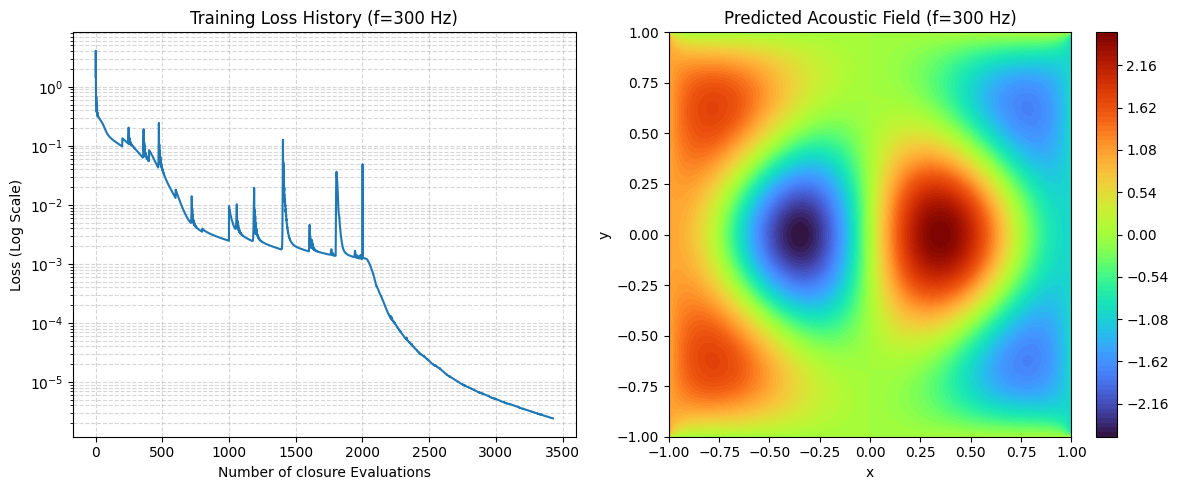

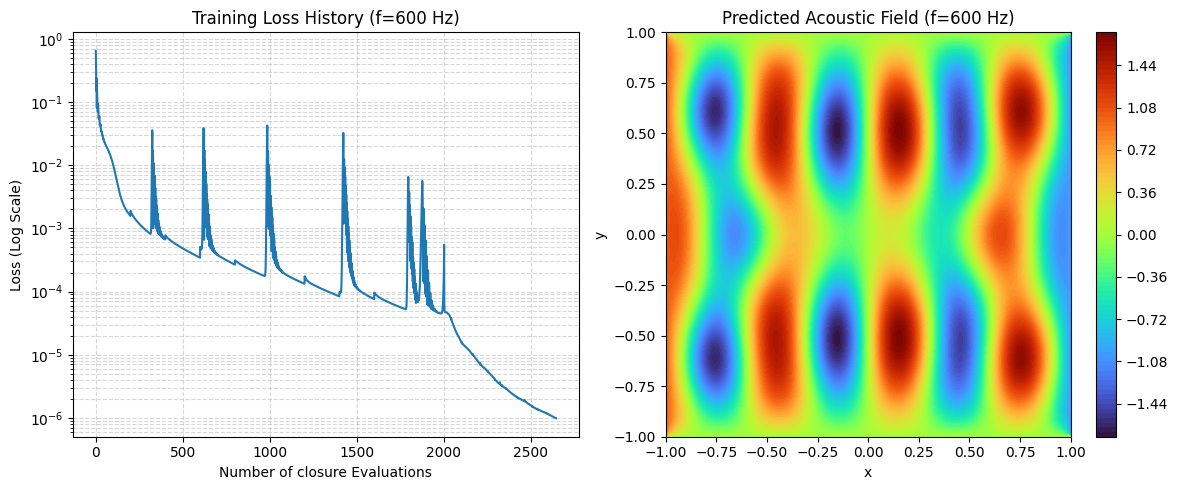

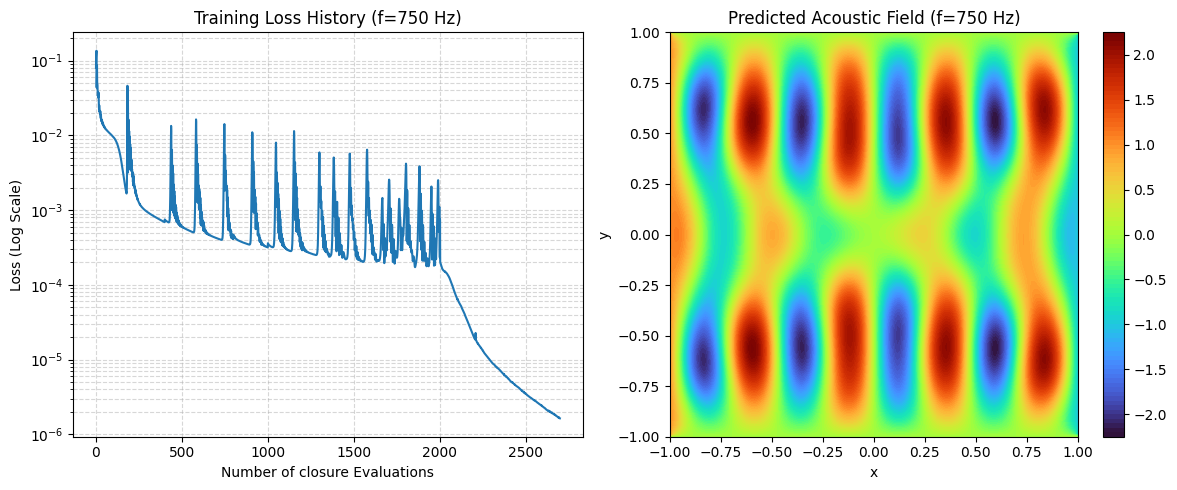

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from time import time

f_set = [ 300, 600, 750 ]
c = 343.0
k_set = [ ( 2.0 * np.pi * f ) / c for f in f_set ]

Nf = 6400
adam_epochs = 2000

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

import torch
import torch.nn as nn
import numpy as np

class Helmholtz_PINN ( nn.Module ):
    def __init__ ( self, n_hidden = 7, hidden_dim = 128, fourier_dim = 16 ):
        super().__init__()

        self.n_hidden = n_hidden
        
        B = torch.randn ( 2, fourier_dim )
        
        self.B = nn.Parameter(B)

        self.input_layer = nn.Linear(2 * fourier_dim, hidden_dim)
        
        self.layers = nn.ModuleList()
        for i in range(n_hidden):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))

        self.output_layer = nn.Linear(hidden_dim, 1)
        
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                m.bias.data.fill_(0.0)

    def forward(self, xy):
        proj = 2.0 * np.pi * xy @ self.B
        ff_out = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        
        out = torch.tanh(self.input_layer(ff_out))
        
        for i in range(self.n_hidden):
            out = torch.tanh(self.layers[i](out))
            
        network_out = self.output_layer(out)

        x = xy[:, 0:1]
        y = xy[:, 1:2]

        den = 2.0 - x**2 - y**2 + 1e-8
        psi_t_I = (-x * (1.0 - y**2)) / den

        phi_e = (1.0 - x**2) * (1.0 - y**2)
        
        psi_t = psi_t_I + phi_e * network_out
        
        return psi_t
        
def net_loss ( model, xy, k, return_pointwise = False ):
    p = model ( xy )
    
    dp_dxy = torch.autograd.grad (
        p, xy, grad_outputs = torch.ones_like ( p ),
        create_graph = True, retain_graph = True
    )[0]
    dp_dx = dp_dxy[:, 0:1]
    dp_dy = dp_dxy[:, 1:2]
    
    d2p_dx2 = torch.autograd.grad (
        dp_dx, xy, grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True, retain_graph = True
    )[0][:, 0:1]
    
    d2p_dy2 = torch.autograd.grad (
        dp_dy, xy, grad_outputs = torch.ones_like ( dp_dy ),
        create_graph = True, retain_graph = True
    )[0][:, 1:2]
    
    residual = ( d2p_dx2 + d2p_dy2 ) / ( k**2 ) + p

    if return_pointwise:
        return torch.abs ( residual )
    return torch.mean ( residual**2 )

xy_f_base = torch.rand ( Nf, 2, device = device ) * 1.96 - 0.98

models = []
loss_histories = []

model = Helmholtz_PINN ( n_hidden = 7, hidden_dim = 128 ).to ( device )

start = time()

for i, k in enumerate ( k_set ):
    
    xy_f = xy_f_base.clone()
    xy_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( f"INFO: Adam Training Started For f = {f_set[i]} Hz" )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                xy_candidate = torch.rand ( 5000, 2, device = device ) * 1.96 - 0.98
            xy_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, xy_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            xy_f = torch.cat ( [ xy_f.detach(), xy_candidate[top_indices].detach() ], dim = 0 )
            xy_f.requires_grad = True
            print ( f"INFO: f = {f_set[i]} Hz; Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )

    print ( f"INFO: Adam Training Done For f = {f_set[i]} Hz\n" )

    define_iters = 30000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( f"INFO: Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )
        return loss

    print ( f"INFO: LBFGS Training Started For f = {f_set[i]} Hz\n" )
    opt.step ( closure )
    print ( f"INFO: LBFGS Training Done For f = {f_set[i]} Hz\n" )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

for idx, k in enumerate ( k_set ): 
    with torch.no_grad():
        x_plot = np.linspace ( -1, 1, 150 )
        y_plot = np.linspace ( -1, 1, 150 )
        X, Y = np.meshgrid ( x_plot, y_plot )
        xy_plot = torch.tensor ( np.column_stack ( ( X.flatten(), Y.flatten() ) ), dtype = torch.float64, device = device )
        
        pred_p = models[idx] ( xy_plot )
        pred_p = pred_p.cpu().numpy().reshape ( 150, 150 )

    fig, axs = plt.subplots ( 1, 2, figsize = ( 12, 5 ) )

    axs[0].plot ( loss_histories[idx] )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss History (f={f_set[idx]} Hz)" )
    axs[0].grid ( True, which = "both", linestyle = "--", alpha = 0.5 )

    p_max = np.max ( np.abs ( pred_p ) )

    c1 = axs[1].contourf ( X, Y, pred_p, 100, cmap = 'turbo', vmin = -p_max, vmax = p_max )
    fig.colorbar ( c1, ax = axs[1] )
    axs[1].set_title ( f"Predicted Acoustic Field (f={f_set[idx]} Hz)" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "y" )

    plt.tight_layout()
    plt.show()

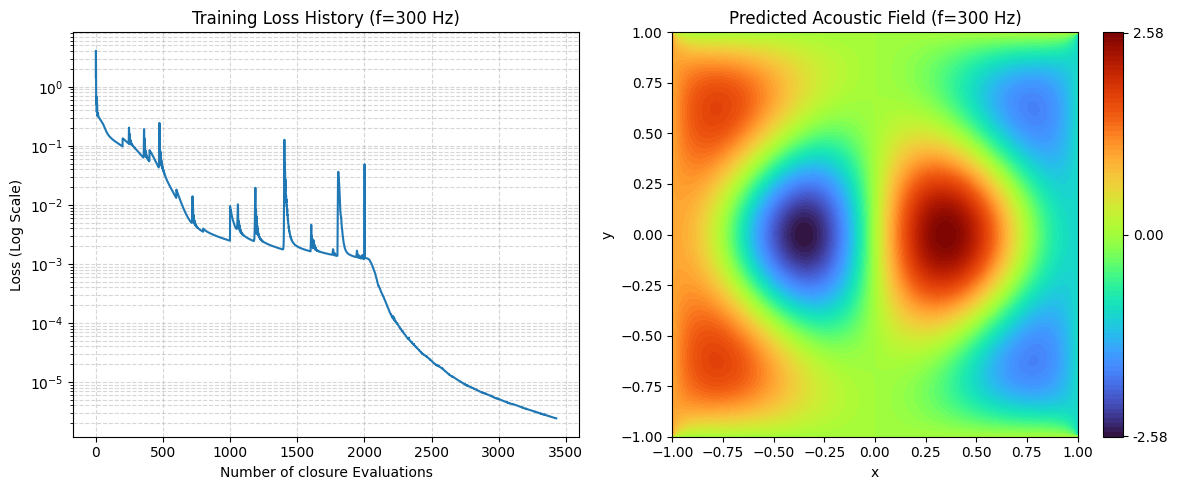

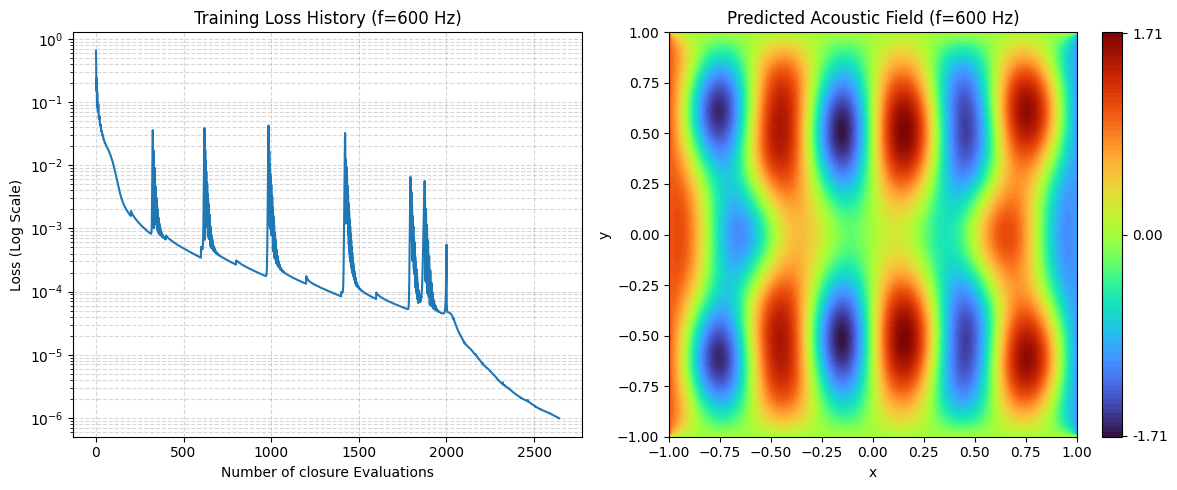

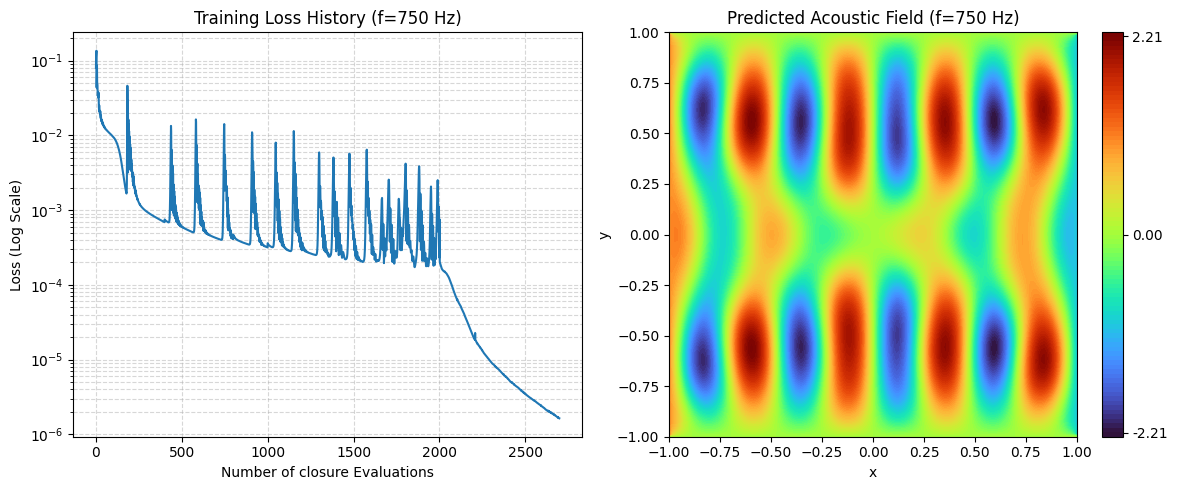

In [10]:
for idx, k in enumerate ( k_set ): 
    with torch.no_grad():
        x_plot = np.linspace ( -1, 1, 150 )
        y_plot = np.linspace ( -1, 1, 150 )
        X, Y = np.meshgrid ( x_plot, y_plot )
        xy_plot = torch.tensor ( np.column_stack ( ( X.flatten(), Y.flatten() ) ), dtype = torch.float64, device = device )
        
        pred_p = models[idx] ( xy_plot )
        pred_p = pred_p.cpu().numpy().reshape ( 150, 150 )

    fig, axs = plt.subplots ( 1, 2, figsize = ( 12, 5 ) )

    axs[0].plot ( loss_histories[idx] )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss History (f={f_set[idx]} Hz)" )
    axs[0].grid ( True, which = "both", linestyle = "--", alpha = 0.5 )

    p_max = np.max ( np.abs ( pred_p ) )

    c1 = axs[1].contourf ( X, Y, pred_p, 100, cmap = 'turbo', vmin = -p_max, vmax = p_max )
    
    cb = fig.colorbar ( c1, ax = axs[1], ticks = [ -p_max, 0, p_max ] )
    
    cb.ax.set_yticklabels ( [ f'{ -p_max:.2f}', '0.00', f'{p_max:.2f}' ] )
    
    axs[1].set_title ( f"Predicted Acoustic Field (f={f_set[idx]} Hz)" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "y" )

    plt.tight_layout()
    plt.show()